<a href="https://colab.research.google.com/github/kaveesha82/DS_Project/blob/component-3/component_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
import re

# ======================
# 1. LOAD THE DATASET
# ======================
print("Step 1: Loading dataset...")

# Define column names based on dataset structure and script usage (17 columns observed in data)
# We include 'location_is_ski' for initial load to match the CSV, then drop it.
column_names = [
    'review_title', 'review_positive', 'review_negative', 'review_score',
    'review_helpful_votes', 'guest_type', 'guest_country', 'room_nights',
    'accommodation_score', 'accommodation_id', 'accommodation_type',
    'accommodation_country', 'accommodation_star_rating', 'location_is_ski',
    'location_is_beach', 'location_is_city_center', 'month'
]

# Load the dataset, specifying no header, and then assign the column names
df = pd.read_csv('/content/drive/MyDrive/DSGP/train.csv', header=None)
df.columns = column_names

# Drop the first row as it contains the actual header from the CSV, now treated as data
df = df.iloc[1:].copy()

# Drop 'location_is_ski' as it's not relevant for Sri Lanka, as per user request
if 'location_is_ski' in df.columns:
    df = df.drop('location_is_ski', axis=1)
    print("  - 'location_is_ski' column dropped as requested.")

# Convert numerical columns to appropriate types after dropping the header row
numerical_cols_to_convert = [
    'review_score', 'review_helpful_votes', 'room_nights',
    'accommodation_score', 'accommodation_star_rating',
    'location_is_beach', 'location_is_city_center'
] # 'location_is_ski' is already dropped
for col in numerical_cols_to_convert:
    # Use errors='coerce' to turn any non-numeric values into NaN
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert 'month' to numeric and ensure it's between 1 and 12, setting others to NaN
df['month'] = pd.to_numeric(df['month'], errors='coerce')
df['month'] = df['month'].apply(lambda x: x if pd.notnull(x) and 1 <= x <= 12 else np.nan)

print(f"Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print("\nFirst look at the data:")
print(df.head())

# ======================
# 2. INITIAL INSPECTION
# ======================
print("\n\n" + "="*50)
print("Step 2: Initial Data Inspection")
print("="*50)

print("\nColumn names and data types:")
print(df.dtypes)

print("\nMissing values in each column:")
missing_summary = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_summary,
    'Percentage (%)': missing_percentage
})
print(missing_df[missing_df['Missing Count'] > 0])

# ======================
# 3. DATA CLEANING
# ======================
print("\n\n" + "="*50)
print("Step 3: Cleaning Data")
print("="*50)

# Create a copy for cleaning
df_clean = df.copy()

# 3.1 Handle missing values
print("\n3.1 Handling missing values...")

# Text columns: Fill with empty string
text_columns = ['review_title', 'review_positive', 'review_negative',
                'guest_type', 'accommodation_type']
for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('')
        print(f"  - {col}: Filled {df[col].isnull().sum()} missing values with empty string")

# Numerical columns: Fill with median (excluding 'month' from median fill if it has many NaNs)
numerical_columns = ['review_score', 'review_helpful_votes', 'room_nights',
                     'accommodation_score', 'accommodation_star_rating',
                     'location_is_beach', 'location_is_city_center']
for col in numerical_columns:
    if col in df_clean.columns:
        median_val = df_clean[col].median()
        df_clean[col] = df_clean[col].fillna(median_val)
        print(f"  - {col}: Filled {df[col].isnull().sum()} missing values with median ({median_val:.2f})")

# For 'month' column, if there are still NaNs after initial cleaning, fill with a valid default or median
# Ensures months are kept within 1-12 and provides a reasonable fill for NaNs.
if 'month' in df_clean.columns and df_clean['month'].isnull().any():
    month_median = df_clean['month'].median()
    # If month_median is NaN (all months are NaN), pick a default, e.g., 6 (June)
    if pd.isnull(month_median):
        df_clean['month'] = df_clean['month'].fillna(6) # Default to June if no valid median
        print(f"  - month: Filled {df_clean['month'].isnull().sum()} missing values with default month (6)")
    else:
        df_clean['month'] = df_clean['month'].fillna(int(month_median))
        print(f"  - month: Filled {df_clean['month'].isnull().sum()} missing values with median month ({int(month_median)}) (ensuring 1-12 range)")


# Country columns: Fill with 'Unknown'
country_columns = ['guest_country', 'accommodation_country']
for col in country_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna('Unknown')
        print(f"  - {col}: Filled {df[col].isnull().sum()} missing values with 'Unknown'")

# 3.2 Standardize text columns
print("\n3.2 Standardizing text columns...")

def clean_text(text):
    """Clean and standardize text data"""
    if isinstance(text, str):
        # Convert to lowercase and remove extra whitespace
        text = text.lower().strip()
        # Remove extra spaces
        text = re.sub(r'\s+', ' ', text)
        # Remove special characters (optional - keep for some analyses)
        # text = re.sub(r'[^\w\s]', '', text)
    return text

for col in text_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_text)
        print(f"  - Cleaned {col}")

# 3.3 Standardize country names (focus on Sri Lanka variations)
print("\n3.3 Standardizing country names...")

def standardize_country(country_name):
    """Standardize country names, especially for Sri Lanka"""
    if not isinstance(country_name, str):
        return country_name

    country_lower = country_name.lower().strip()

    # Common variations for Sri Lanka
    sri_lanka_variations = [
        'sri lanka', 'sri lankan', 'srilanka', 'lk',
        'ceylon', 'ලංකාව', 'இலங்கை'
    ]

    for variation in sri_lanka_variations:
        if variation in country_lower or country_lower in variation:
            return 'sri lanka'

    # Add more country standardization as needed
    country_mapping = {
        'usa': 'united states', 'us': 'united states', 'america': 'united states',
        'uk': 'united kingdom', 'england': 'united kingdom', 'britain': 'united kingdom',
        'uae': 'united arab emirates', 'dubai': 'united arab emirates'
    }

    return country_mapping.get(country_lower, country_lower)

for col in country_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(standardize_country)
        print(f"  - Standardized {col}")

# 3.4 Filter for Sri Lanka accommodations only
print("\n3.4 Filtering for Sri Lanka accommodations...")
initial_count = len(df_clean)
df_sri_lanka = df_clean[df_clean['accommodation_country'] == 'sri lanka'].copy()
print(f"  - Filtered from {initial_count} to {len(df_sri_lanka)} rows ({len(df_sri_lanka)/initial_count*100:.1f}%) represents ")

# 3.5 Clean and standardize scores
print("\n3.5 Standardizing scores...")

# Ensure review_score is on a consistent scale (1-10 or 1-5)
if 'review_score' in df_sri_lanka.columns:
    max_score = df_sri_lanka['review_score'].max()
    if max_score <= 5:
        # Scale 1-5 to 1-10 for consistency
        df_sri_lanka['review_score_normalized'] = df_sri_lanka['review_score'] * 2
        print(f"  - review_score scaled from 1-5 to 1-10 (max was {max_score})")
    elif max_score <= 10:
        df_sri_lanka['review_score_normalized'] = df_sri_lanka['review_score']
        print(f"  - review_score already on 1-10 scale")
    else:
        # If scale is different, normalize to 1-10
        df_sri_lanka['review_score_normalized'] = (
            (df_sri_lanka['review_score'] - df_sri_lanka['review_score'].min()) /
            (df_sri_lanka['review_score'].max() - df_sri_lanka['review_score'].min())
        ) * 9 + 1  # Scale to 1-10
        print(f"  - review_score normalized from {df_sri_lanka['review_score'].min():.1f}-{df_sri_lanka['review_score'].max():.1f} to 1-10")

# ======================
# 4. FEATURE ENGINEERING
# ======================
print("\n\n" + "="*50)
print("Step 4: Feature Engineering")
print("="*50)

# 4.1 Guest & Stay Profile Features
print("\n4.1 Creating guest and stay profile features...")

# Stay length category
def categorize_stay_length(nights):
    if nights <= 2:
        return 'short (1-2 nights)'
    elif nights <= 5:
        return 'medium (3-5 nights)'
    elif nights <= 10:
        return 'long (6-10 nights)'
    else:
        return 'extended (11+ nights)'

df_sri_lanka['stay_length_category'] = df_sri_lanka['room_nights'].apply(categorize_stay_length)

# Domestic guest flag
df_sri_lanka['is_domestic_guest'] = df_sri_lanka['guest_country'] == 'sri lanka'

print(f"  - Created stay_length_category")
print(f"  - Created is_domestic_guest: {df_sri_lanka['is_domestic_guest'].sum()} domestic guests")

# 4.2 Review & Sentiment Features
print("\n4.2 Creating review and sentiment features...")

# Review text length features
df_sri_lanka['positive_review_length'] = df_sri_lanka['review_positive'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else 0
)
df_sri_lanka['negative_review_length'] = df_sri_lanka['review_negative'].apply(
    lambda x: len(str(x).split()) if pd.notnull(x) else 0
)

# Sentiment polarity (simplified)
df_sri_lanka['sentiment_polarity'] = df_sri_lanka.apply(
    lambda row: row['positive_review_length'] /
    (row['positive_review_length'] + row['negative_review_length'] + 0.001),  # Add small value to avoid division by zero
    axis=1
)

# Helpfulness flag (removed as per user request)
# df_sri_lanka['review_helpful'] = df_sri_lanka['review_helpful_votes'] > 0
# print(f"  - Created review_helpful: {df_sri_lanka['review_helpful'].sum()} helpful reviews")

print(f"  - Created positive_review_length")
print(f"  - Created negative_review_length")
print(f"  - Created sentiment_polarity")

# 4.3 Accommodation & Location Features
print("\n4.3 Creating accommodation and location features...")

# Score delta (guest rating vs accommodation average)
if 'review_score_normalized' in df_sri_lanka.columns and 'accommodation_score' in df_sri_lanka.columns:
    df_sri_lanka['score_delta'] = df_sri_lanka['review_score_normalized'] - df_sri_lanka['accommodation_score']
    print(f"  - Created score_delta")

# Location profile
def create_location_profile(row):
    """Create a location profile based on the location flags"""
    location_parts = []

    if row.get('location_is_beach', 0) == 1:
        location_parts.append('beach')
    if row.get('location_is_city_center', 0) == 1:
        location_parts.append('city')
    # 'location_is_ski' is now dropped from the DataFrame before this function is called.

    if not location_parts:
        return 'other'
    elif len(location_parts) == 1:
        return location_parts[0]
    else:
        return '_'.join(location_parts)

df_sri_lanka['location_profile'] = df_sri_lanka.apply(create_location_profile, axis=1)
print(f"  - Created location_profile")

# ======================
# 5. FINAL VALIDATION
# ======================
print("\n\n" + "="*50)
print("Step 5: Final Data Validation")
print("="*50)

print(f"\nFinal dataset shape: {df_sri_lanka.shape}")
print(f"\nMissing values summary:")
print(df_sri_lanka.isnull().sum().sort_values(ascending=False).head(10))

print(f"\nSample of cleaned data (first 3 rows):")
print(df_sri_lanka.head(3).T)  # Transposed for better readability

print(f"\nNew features created:")
# Manually define new_features based on what is actually created and kept
new_features = [
    'review_score_normalized',
    'stay_length_category',
    'is_domestic_guest',
    'positive_review_length',
    'negative_review_length',
    'sentiment_polarity',
    'score_delta',
    'location_profile'
]
print(f"  Total new features: {len(new_features)}")
for i, feat in enumerate(new_features, 1):
    print(f"  {i}. {feat}")

# ======================
# 6. SAVE CLEANED DATASET
# ======================
print("\n\n" + "="*50)
print("Step 6: Saving Cleaned Dataset")
print("="*50)

# Save to new CSV file
output_filename = '/content/drive/MyDrive/DSGP/sri_lanka_tourism_cleaned.csv'
df_sri_lanka.to_csv(output_filename, index=False)
print(f"\n Cleaned dataset saved as '{output_filename}'")
print(f"   Location: {output_filename}")

# Optional: Save a summary report
summary_stats = {
    'original_rows': len(df),
    'sri_lanka_rows': len(df_sri_lanka),
    'columns_original': len(df.columns),
    'columns_final': len(df_sri_lanka.columns),
    'new_features': len(new_features),
    'domestic_guests': df_sri_lanka['is_domestic_guest'].sum(),
    'foreign_guests': (~df_sri_lanka['is_domestic_guest']).sum(),
    'avg_review_score': df_sri_lanka['review_score_normalized'].mean() if 'review_score_normalized' in df_sri_lanka.columns else 'N/A',
    'most_common_accommodation': df_sri_lanka['accommodation_type'].mode()[0] if 'accommodation_type' in df_sri_lanka.columns else 'N/A'
}

print("\n Dataset Summary:")
for key, value in summary_stats.items():
    print(f"  - {key.replace('_', ' ').title()}: {value}")

print("\n Data cleaning and feature engineering complete!")

Step 1: Loading dataset...


/tmp/ipython-input-2175059824.py:22: DtypeWarning: Columns (3,4,7,8,9,12,13,14,15,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('/content/drive/MyDrive/DSGP/train.csv', header=None)


  - 'location_is_ski' column dropped as requested.
Dataset loaded: 1628989 rows, 16 columns

First look at the data:
                      review_title  \
1                              NaN   
2  Fantastic location and  service   
3           Great central location   
4  Great place in a great location   
5                   Fantastic find   

                                     review_positive  \
1               Beautiful bathroom, comfortable bed.   
2  Great location and easy to get to  The view fr...   
3           Central location, friendly helpful staff   
4  Room was very spacious and the king size bed w...   
5  This was perfect in every way - close to the s...   

                                     review_negative  review_score  \
1      No robes were provided.  No couches in rooms.           7.0   
2                                                NaN           8.0   
3  No aircon, no access back to hotel from hotel ...           7.0   
4  Noise from upstairs was loud and m

In [ ]:
pip install pandas numpy vaderSentiment matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.0/126.0 kB 2.8 MB/s eta 0:00:00


Loading dataset...

DATASET OVERVIEW
Dataset shape: (8896, 24)

First 5 rows:
                                review_title                                    review_positive                       review_negative  review_score  review_helpful_votes      guest_type guest_country  room_nights  accommodation_score  accommodation_id accommodation_type accommodation_country  accommodation_star_rating  location_is_beach  location_is_city_center  month  review_score_normalized stay_length_category  is_domestic_guest  positive_review_length  negative_review_length  sentiment_polarity  score_delta location_profile
0         beautiful hotel right at the beach  the set up of the hotel is just beautiful and ...                                                 9.0                     0  solo traveller         qehoj            2                    5        1521443975              hotel             sri lanka                        8.5                  0                        1    1.0                  

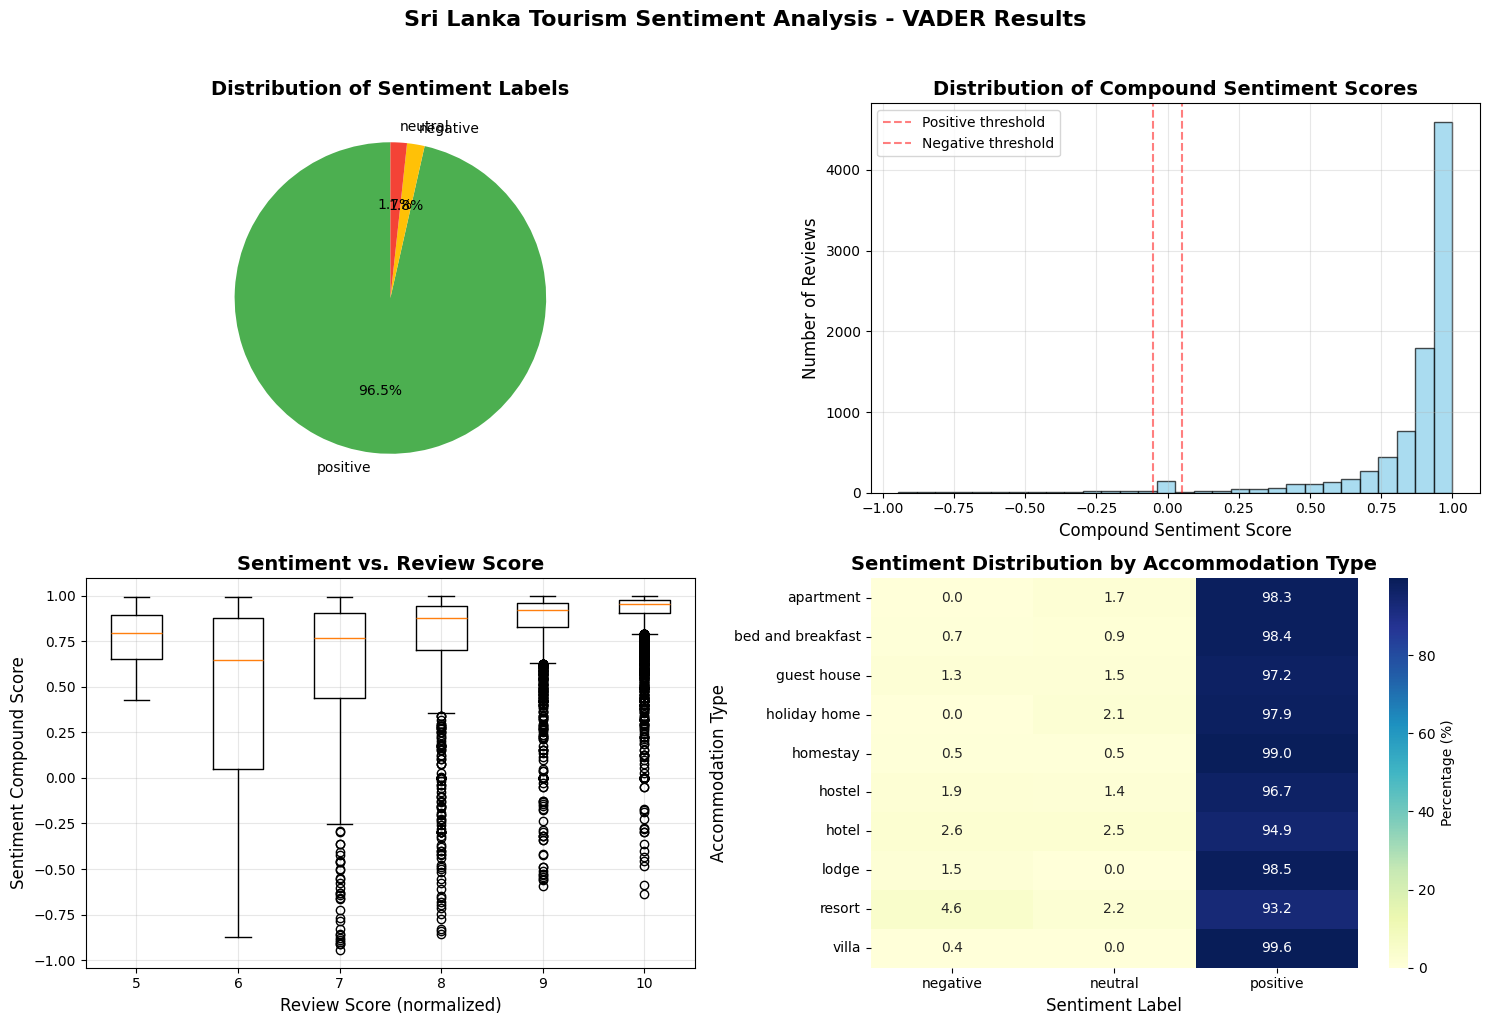


RESULTS SAVED TO: tourism_reviews_with_sentiment.csv
File contains 8896 reviews with sentiment analysis
Columns saved: ['review_full', 'review_score_normalized', 'accommodation_type', 'guest_country', 'location_profile', 'stay_length_category', 'sentiment_compound', 'sentiment_label', 'sentiment_neg', 'sentiment_neu', 'sentiment_pos']

STEP 1-3 COMPLETE: NEXT STEPS
Dataset loaded and explored
Aspect categories defined for future analysis
VADER sentiment analysis completed on all reviews
Sentiment labels assigned (Positive/Neutral/Negative)
Visualizations generated
Results saved to CSV for dashboard integration


In [ ]:
# ============================================
# STEP 1: ENVIRONMENT & DATA SETUP
# ============================================

import pandas as pd
import numpy as np
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options for better viewing
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.width', 1000)

# Load your dataset
print("Loading dataset...")
df = pd.read_csv('/content/drive/MyDrive/DSGP/sri_lanka_tourism_cleaned.csv')

# Ensure review columns are strings and fill NaNs before any slicing or processing
df['review_positive'] = df['review_positive'].fillna('').astype(str)
df['review_negative'] = df['review_negative'].fillna('').astype(str)

# Explore the structure
print("\n" + "="*50)
print("DATASET OVERVIEW")
print("="*50)
print(f"Dataset shape: {df.shape}")  # (rows, columns)
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nDataset info:")
print(df.info())
print(f"\nColumn names: {list(df.columns)}")

# Check key columns
print("\n" + "="*50)
print("CHECKING REVIEW COLUMNS")
print("="*50)
print(f"Positive review sample: {df['review_positive'].iloc[0][:100]}...")
print(f"Negative review sample: {df['review_negative'].iloc[0][:100]}...")
print(f"\nMissing values in review columns:")
print(f"review_positive: {df['review_positive'].isna().sum()} missing")
print(f"review_negative: {df['review_negative'].isna().sum()} missing")

# ============================
# STEP 2: DEFINE YOUR ASPECTS
# ===========================

# define these aspects for use in later steps
aspect_categories = {
    'service': ['staff', 'service', 'host', 'friendly', 'helpful', 'hospitality', 'attentive'],
    'location': ['location', 'view', 'beach', 'city', 'center', 'close', 'walking distance', 'near'],
    'room': ['room', 'clean', 'bed', 'bathroom', 'shower', 'AC', 'air conditioning', 'spacious'],
    'food': ['food', 'breakfast', 'dinner', 'restaurant', 'meal', 'delicious', 'tasty'],
    'value': ['price', 'value', 'money', 'cheap', 'expensive', 'worth', 'cost'],
    'facilities': ['pool', 'wifi', 'internet', 'facilities', 'amenities', 'parking', 'garden']
}

print("\n" + "="*50)
print("ASPECT CATEGORIES DEFINED")
print("="*50)
for category, keywords in aspect_categories.items():
    print(f"{category.capitalize()}: {keywords}")

# ============================================
# STEP 3: LEXICON-BASED SENTIMENT ANALYSIS WITH VADER
# ============================================

print("\n" + "="*50)
print("RUNNING VADER SENTIMENT ANALYSIS")
print("="*50)

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Combine positive and negative review text for comprehensive analysis
# Handle NaN values by filling with empty strings
# These operations are now handled earlier to prevent slicing errors.
df['review_full'] = df['review_positive'] + ' ' + df['review_negative']

# Clean text: remove extra spaces and ensure proper string format
df['review_full'] = df['review_full'].str.strip()
df['review_full'] = df['review_full'].fillna('')

# Function to get VADER sentiment scores
def get_vader_sentiment(text):
    if isinstance(text, str) and len(text.strip()) > 0:
        scores = analyzer.polarity_scores(text)
        return scores
    else:
        # Return neutral scores for empty text
        return {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

# Apply sentiment analysis to all reviews
print("Analyzing sentiment for each review...")
df['vader_scores'] = df['review_full'].apply(get_vader_sentiment)

# Extract compound score (overall sentiment from -1 to +1)
df['sentiment_compound'] = df['vader_scores'].apply(lambda x: x['compound'])

# Extract individual scores
df['sentiment_neg'] = df['vader_scores'].apply(lambda x: x['neg'])
df['sentiment_neu'] = df['vader_scores'].apply(lambda x: x['neu'])
df['sentiment_pos'] = df['vader_scores'].apply(lambda x: x['pos'])

# Create sentiment labels based on compound score
def categorize_sentiment(compound_score):
    if compound_score >= 0.05:
        return 'positive'
    elif compound_score <= -0.05:
        return 'negative'
    else:
        return 'neutral'

df['sentiment_label'] = df['sentiment_compound'].apply(categorize_sentiment)

# ============================================
# DISPLAY RESULTS
# ============================================

print("\n" + "="*50)
print("SENTIMENT ANALYSIS RESULTS")
print("="*50)

# Display sample reviews with their sentiment
sample_reviews = df[['review_full', 'sentiment_compound', 'sentiment_label']].head(10)
print("\nSample reviews with sentiment scores:")
for idx, row in sample_reviews.iterrows():
    print(f"\nReview {idx+1}: {row['review_full'][:100]}...")
    print(f"Compound Score: {row['sentiment_compound']:.3f} | Label: {row['sentiment_label']}")

# Summary statistics
print("\n" + "="*50)
print("SENTIMENT DISTRIBUTION")
print("="*50)
sentiment_counts = df['sentiment_label'].value_counts()
sentiment_percentages = df['sentiment_label'].value_counts(normalize=True) * 100

for label in ['positive', 'neutral', 'negative']:
    count = sentiment_counts.get(label, 0)
    percentage = sentiment_percentages.get(label, 0)
    print(f"{label.capitalize()}: {count} reviews ({percentage:.1f}%)")

# Display overall statistics
print(f"\nOverall sentiment statistics:")
print(f"Average compound score: {df['sentiment_compound'].mean():.3f}")
print(f"Median compound score: {df['sentiment_compound'].median():.3f}")
print(f"Min compound score: {df['sentiment_compound'].min():.3f}")
print(f"Max compound score: {df['sentiment_compound'].max():.3f}")

# ============================================
# VISUALIZE RESULTS
# ============================================

print("\n" + "="*50)
print("GENERATING VISUALIZATIONS")
print("="*50)

# Set up the figure
plt.figure(figsize=(15, 10))

# Plot 1: Sentiment distribution pie chart
plt.subplot(2, 2, 1)
colors = ['#4CAF50', '#FFC107', '#F44336']  # Green, Yellow, Red
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=90)
plt.title('Distribution of Sentiment Labels', fontsize=14, fontweight='bold')

# Plot 2: Histogram of compound scores
plt.subplot(2, 2, 2)
plt.hist(df['sentiment_compound'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.axvline(x=0.05, color='red', linestyle='--', alpha=0.5, label='Positive threshold')
plt.axvline(x=-0.05, color='red', linestyle='--', alpha=0.5, label='Negative threshold')
plt.xlabel('Compound Sentiment Score', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.title('Distribution of Compound Sentiment Scores', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 3: Box plot of sentiment by review score
plt.subplot(2, 2, 3)
if 'review_score_normalized' in df.columns:
    # Group by rounded review score for better visualization
    df['review_score_rounded'] = df['review_score_normalized'].round()
    sentiment_by_score = []
    scores = sorted(df['review_score_rounded'].unique())

    for score in scores:
        sentiment_by_score.append(df[df['review_score_rounded'] == score]['sentiment_compound'].values)

    # Change 'labels' to 'tick_labels' as per the deprecation warning
    plt.boxplot(sentiment_by_score, tick_labels=[str(int(s)) for s in scores])
    plt.xlabel('Review Score (normalized)', fontsize=12)
    plt.ylabel('Sentiment Compound Score', fontsize=12)
    plt.title('Sentiment vs. Review Score', fontsize=14, fontweight='bold')
    plt.grid(True, alpha=0.3)

# Plot 4: Sentiment by accommodation type
plt.subplot(2, 2, 4)
if 'accommodation_type' in df.columns:
    # Get top 10 accommodation types
    top_types = df['accommodation_type'].value_counts().head(10).index
    df_top = df[df['accommodation_type'].isin(top_types)]

    # Create a pivot table for heatmap
    pivot_data = pd.crosstab(df_top['accommodation_type'], df_top['sentiment_label'])
    pivot_data = pivot_data.div(pivot_data.sum(axis=1), axis=0) * 100  # Convert to percentages

    sns.heatmap(pivot_data, annot=True, fmt='.1f', cmap='YlGnBu', cbar_kws={'label': 'Percentage (%)'})
    plt.title('Sentiment Distribution by Accommodation Type', fontsize=14, fontweight='bold')
    plt.xlabel('Sentiment Label', fontsize=12)
    plt.ylabel('Accommodation Type', fontsize=12)
    plt.tight_layout()

plt.suptitle('Sri Lanka Tourism Sentiment Analysis - VADER Results', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================
# SAVE THE RESULTS
# ============================================

# Create a new DataFrame with key columns for the dashboard
dashboard_columns = [
    'review_full', 'review_score_normalized', 'accommodation_type',
    'guest_country', 'location_profile', 'stay_length_category',
    'sentiment_compound', 'sentiment_label', 'sentiment_neg',
    'sentiment_neu', 'sentiment_pos'
]

# Select only columns that exist in the DataFrame
available_columns = [col for col in dashboard_columns if col in df.columns]
df_dashboard = df[available_columns]

# Save to a new CSV file
output_filename = 'tourism_reviews_with_sentiment.csv'
df_dashboard.to_csv(output_filename, index=False)

print(f"\n" + "="*50)
print(f"RESULTS SAVED TO: {output_filename}")
print("="*50)
print(f"File contains {len(df_dashboard)} reviews with sentiment analysis")
print(f"Columns saved: {list(df_dashboard.columns)}")

# ============================================
# FINAL SUMMARY
# ============================================

print("\n" + "="*50)
print("STEP 1-3 COMPLETE: NEXT STEPS")
print("="*50)
print("Dataset loaded and explored")
print("Aspect categories defined for future analysis")
print("VADER sentiment analysis completed on all reviews")
print("Sentiment labels assigned (Positive/Neutral/Negative)")
print("Visualizations generated")
print("Results saved to CSV for dashboard integration")

# NEXT: Proceed to Step 4 - Zero-Shot Aspect-Based Analysis
#       This will analyze which specific aspects (service, location, etc.)
#       are mentioned in each review and their sentiment.

In [ ]:
from transformers import pipeline

# Option 1: Facebook's BART (accurate but slower)
classifier = pipeline("zero-shot-classification",
                      model="facebook/bart-large-mnli")

# Option 2: DistilBERT (faster, good for larger datasets)
# classifier = pipeline("zero-shot-classification",
#                      model="typeform/distilbert-base-uncased-mnli")

# Your defined aspects
aspect_labels = [
    "service and staff",
    "location and view",
    "room and cleanliness",
    "food and breakfast",
    "value for money",
    "facilities and amenities"
]

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Device set to use cpu


In [ ]:
def analyze_aspects_zero_shot(review_text, classifier, labels):
    """
    Use zero-shot classification to identify which aspects are mentioned
    and determine their sentiment orientation
    """
    try:
        # Classify which aspects are present
        result = classifier(review_text, labels, multi_label=True)

        # Get aspects with confidence > threshold (e.g., 0.3)
        threshold = 0.3
        aspects_present = []

        for label, score in zip(result['labels'], result['scores']):
            if score > threshold:
                aspects_present.append({
                    'aspect': label,
                    'confidence': score
                })

        return aspects_present
    except Exception as e:
        print(f"Error analyzing review: {e}")
        return []

# Apply to a sample first (to test)
print("Analyzing aspects for sample reviews...")
sample_reviews = df['review_full'].head(100).tolist()
for i, review in enumerate(sample_reviews[:5]):
    if review.strip():
        aspects = analyze_aspects_zero_shot(review, classifier, aspect_labels)
        print(f"\nReview {i+1}: {review[:100]}...")
        print(f"Aspects mentioned: {aspects}")

Analyzing aspects for sample reviews...

Review 1: the set up of the hotel is just beautiful and right at the beach! the sound of the waves was so rela...
Aspects mentioned: [{'aspect': 'service and staff', 'confidence': 0.998258113861084}, {'aspect': 'value for money', 'confidence': 0.9979344606399536}, {'aspect': 'facilities and amenities', 'confidence': 0.9946922659873962}, {'aspect': 'location and view', 'confidence': 0.9928542375564575}, {'aspect': 'room and cleanliness', 'confidence': 0.3754997253417969}]

Review 2: spacious and clean room with lovely balcony area overlooking the trees and surrounding mountains. tr...
Aspects mentioned: [{'aspect': 'value for money', 'confidence': 0.9995089769363403}, {'aspect': 'service and staff', 'confidence': 0.999488115310669}, {'aspect': 'room and cleanliness', 'confidence': 0.9987753629684448}, {'aspect': 'location and view', 'confidence': 0.9973552823066711}, {'aspect': 'facilities and amenities', 'confidence': 0.9965019822120667}, {'aspe

In [ ]:
# Create new columns for each aspect with sentiment score
for aspect in aspect_labels:
    df[f'aspect_{aspect.replace(" ", "_")}'] = 0.0
    df[f'aspect_{aspect.replace(" ", "_")}_confidence'] = 0.0

# Function to analyze all reviews (run this in batches for memory efficiency)
def batch_process_aspects(df, classifier, batch_size=50):
    """Process reviews in batches to avoid memory issues"""

    print(f"Processing {len(df)} reviews in batches of {batch_size}...")

    for i in range(0, len(df), batch_size):
        batch = df.iloc[i:i+batch_size]
        for idx, row in batch.iterrows():
            review_text = row['review_full']

            if pd.notnull(review_text) and review_text.strip():
                # Get VADER sentiment for context
                base_sentiment = row['sentiment_compound']

                # Get aspects
                aspects = analyze_aspects_zero_shot(review_text, classifier, aspect_labels)

                # Update DataFrame
                for aspect_info in aspects:
                    aspect_name = aspect_info['aspect'].replace(" ", "_")
                    confidence = aspect_info['confidence']

                    # Store both presence and weighted sentiment
                    df.at[idx, f'aspect_{aspect_name}'] = 1
                    df.at[idx, f'aspect_{aspect_name}_confidence'] = confidence

                    # You could also create sentiment-weighted scores
                    df.at[idx, f'aspect_{aspect_name}_sentiment'] = base_sentiment * confidence

        # Progress update
        if (i // batch_size) % 5 == 0:
            print(f"  Processed {min(i+batch_size, len(df))}/{len(df)} reviews...")

    return df

# Process all reviews (start with small batch to test)
df_sample = df.head(200)  # Start with 200 reviews
df_sample = batch_process_aspects(df_sample, classifier, batch_size=20)

Processing 200 reviews in batches of 20...


/tmp/ipython-input-644543644.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.at[idx, f'aspect_{aspect_name}_sentiment'] = base_sentiment * confidence
/tmp/ipython-input-644543644.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.at[idx, f'aspect_{aspect_name}_sentiment'] = base_sentiment * confidence
/tmp/ipython-input-644543644.py:34: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the cav

  Processed 20/200 reviews...
  Processed 120/200 reviews...


KeyboardInterrupt: 